# Model error (e3sm_diags PCC/RMSE) — alternate spin-ups vs Full-CPL

Figures (`comparison_period` in the file name):
* `SEAS1_exp3_PCC_RMSEz_<period>.pdf` — (a) PCC, (b) normalized RMSE z = (RMSE − piControl mean) / σ
* `SEAS1_exp3_PCC_RMSEz_regions_<period>.pdf` — same for tropics, mid-latitudes and high latitudes

σ is the standard deviation of the 50-yr RMSE over model years 351–2500 of the Full-CPL system (spin-up 0351–2000 + piControl).

**Setup** holds everything you normally change: paths, the experiment table, labels, colors and years. Each analysis step then has a **settings** cell (its parameters and plot style) and a **compute & plot** cell that calls the shared classes in `../util/` directly. Figures are saved to `FIG_DIR` (public_html) and cached/derived data to `DATA_DIR` (public_html `data/`, indexed in `data/README.md`).

In [1]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import os
import re
import io
import contextlib
import glob
import string
import json
import numpy as np
import xarray as xr
import cftime
import fnmatch
import pandas as pd
import seaborn as sns
from collections import OrderedDict
from scipy.stats import linregress

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter, FixedLocator
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm,ListedColormap
import matplotlib as mpl
from matplotlib.patches import Polygon, Patch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable

from util.experiments import build_exp_subdirs_from_run_dict, make_run_dict
from util.figures import publish
from util.model_error import SpinupMetricAnalyzer

## Setup

In [2]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/model_error_compare"
DATA_DIR     = f"{OUTPUT_ROOT}/data/model_error_compare"   # cached/derived data (index: data/README.md)
OBS_DIR      = f"{OUTPUT_ROOT}/data/obs"                                          # HadSST Nino3.4 reference

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG3": {
        "spin-up":   {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-2000"},
        "piControl": {"name": "20241105.v3.LR.piControl.Rerun.BC2GC.anvil",     "period": "0001-0500"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}

# ---- analysis settings ----
EXPS        = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared (plotting order)


In [3]:
# Shared inputs/outputs
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

figures -> /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_compare
web     -> https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_compare


## 1 Seasonal PCC/RMSE metrics

[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 1 variables have no finite values across periods: AODDUST
[INFO] Bias: 1 variables have no finite values across periods: AODDUST
[INFO] PCC: 1 variables have no finite values across periods: AODDUST


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] Bias: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] PCC: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 1 variables have no finite values across periods: AODDUST
[INFO] Bias: 1 variables have no finite values across periods: AODDUST
[INFO] PCC: 1 variables have no finite values across periods: AODDUST


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] Bias: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN
[INFO] PCC: 2 variables have no finite values across periods: AODDUST, TGCLDLWP_OCN


/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)
/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/coupled_spinup_evaluation/util/model_error.py:614: RuntimeWarning: Mean of empty slice
  return np.nanmean(x[idx, :], axis=0)


[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0301-0350
[INFO] Catalog filter: matched rows=68, matched base vars=68
[INFO] Loaded metrics for 68 variables (all selected).
[INFO] Collapsed per metric: kept 68 base variables with per-metric best obs.
[INFO] RMSE: 1 variables have no finite values across periods: AODDUST
[INFO] Bias: 1 variables have no finite values across periods: AODDUST
[INFO] PCC: 1 variables have no finite values across periods: AODDUST
[INFO] Wrote diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_DJF_global.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_DJF_global.nc
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0301-0350
[INFO] Catalog filt

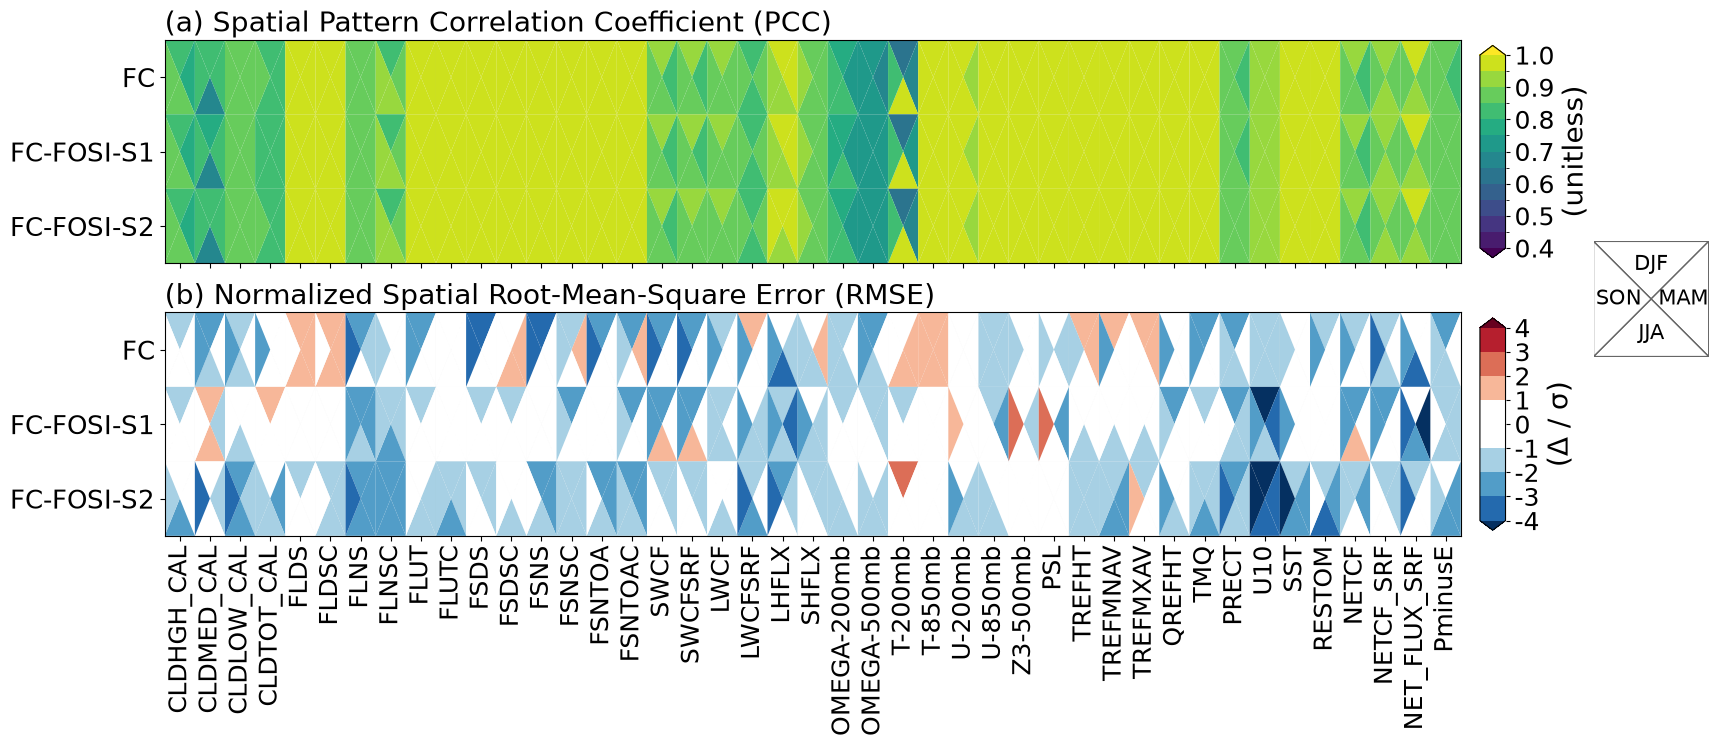

[INFO] Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_compare/SEAS1_exp3_PCC_RMSEz_0301-0350.pdf
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] All comparison plots generated successfully.
web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_compare


In [4]:
data_dir    = f"{OUTPUT_ROOT}/data/diag_data"   # e3sm_diags seasonal metrics tables
out_dir     = DATA_DIR
fig_dir     = FIG_DIR
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

experiments    = EXPS
explabels      = [LABEL[t] for t in EXPS]

spinup_names   = [ run_dict[e]["spin-up"]["name"] for e in experiments ]
picontrol_name = run_dict["Full-CPL"]["piControl"]["name"]

# NOTE: if your CSVs use 0251-0300 instead of 0201-0250, change this label to match.
comparison_period   = "0301-0350"    # the single 50-yr window to compare across spin-ups

# Use the full 500-yr piControl mean as reference
reference_window_pi = (1, 500)

strategy_map  = {"Mean_Bias": "min_abs", "RMSE": "min", "Correlation": "max"}
obs_priority  = ["GPCP", "CMAP", "ERA5"]

seasons = ["DJF", "MAM", "JJA", "SON"]

# Spin-ups must cover at least the end of the target window (i.e., 250)
spinup_years = 350
# Do not read beyond 250 from piControl for spin-ups
picontrol_switch_year = 250

dtype = "float32"

# Internal-variability σ of RMSE (for the Δ/σ figure, rmse_mode="z"): per variable/season, the
# sample std of the 50-yr RMSE over the Full-CPL spin-up windows starting in sigma_spinup_years
# followed by the 500-yr piControl, i.e. model years 0351-2500 (33 + 10 windows; the period used
# for the long-term linear trends in the other figures). Not detrended,
# so slow RMSE drift counts as variability; floored at floor_frac*|mean|.
sigma_case         = run_dict["Full-CPL"]["spin-up"]["name"]
sigma_spinup_years = (351, 2000)
sigma_kw = dict(detrend=False, method="std", floor_frac=0.001)
debug = True 

# OPTIONAL plot-catalog
plt_dict_file = os.path.join(WF_ROOT, "config", "pltvar_region_sources.json")
use_catalog = os.path.isfile(plt_dict_file)

def sigma_rmse_table(base_dir, df_rmse_pi, season):
    """RMSE (window x variable) for σ: Full-CPL spin-up windows in sigma_spinup_years, then the
    piControl windows (df_rmse_pi) relabelled to follow them (0001-0050 -> 2001-2050)."""
    an = SpinupMetricAnalyzer(
        base_dir=base_dir, spinup_name=sigma_case, picontrol_name=None, season=season,
        reference_period=None, reference_window=None,
        spinup_years=sigma_spinup_years[1], picontrol_switch_year=sigma_spinup_years[1],
    )
    if use_catalog:
        an.use_plot_catalog(plt_dict_file)
    with contextlib.redirect_stdout(io.StringIO()):     # quiet: windows before the σ span are missing
        an.extract_metrics()
        an.select_periods([p for p in an.tables["RMSE"].columns if int(p[:4]) >= sigma_spinup_years[0]])
        an.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=False)
        an.build_dataset()
    df_sp = an.ds["RMSE"].to_pandas()
    an.close()
    shift = lambda p: "-".join(f"{int(y) + sigma_spinup_years[1]:04d}" for y in p.split("-"))
    return pd.concat([df_sp, df_rmse_pi.rename(index=shift)])

# ------------------------------------------------------------
# 1) Build a piControl-only analyzer to derive reference vectors
# ------------------------------------------------------------
ref_vectors_by_season = {}  # season -> {"Mean_Bias": {var: val}, "RMSE": {...}, "Correlation": {...}}
for s in seasons:
    an_ref = SpinupMetricAnalyzer(
        base_dir=data_dir,
        spinup_name=picontrol_name,     # read the piControl experiment directly
        picontrol_name=None,            # no switching; only piControl CSVs are used
        season=s,
        reference_period=None,
        reference_window=reference_window_pi,  # mean across starts in [1,500]
        spinup_years=500,                        # <-- read all 500 years
        picontrol_switch_year=500,
    )
    if use_catalog:
        an_ref.use_plot_catalog(plt_dict_file)

    an_ref.extract_metrics()
    an_ref.set_obs_priority(obs_priority)
    an_ref.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=False)
    an_ref.build_dataset()

    # Per-metric reference = mean across all periods (500-yr)
    df_bias = an_ref.ds["Bias"].to_pandas()
    df_rmse = an_ref.ds["RMSE"].to_pandas()
    df_pcc  = an_ref.ds["PCC"].to_pandas()
    ref_vectors_by_season[s] = {
        "Mean_Bias":  {str(v): float(df_bias[v].mean(skipna=True)) for v in df_bias.columns},
        "RMSE":       {str(v): float(df_rmse[v].mean(skipna=True)) for v in df_rmse.columns},
        "Correlation":{str(v): float(df_pcc[v].mean(skipna=True))  for v in df_pcc.columns},
        "RMSE_sigma": SpinupMetricAnalyzer.piControl_sigma_vector(sigma_rmse_table(data_dir, df_rmse, s), **sigma_kw),
    }
    an_ref.close()

# ------------------------------------------------------------
# 2) Build analyzers for each spin-up experiment/season
#    and inject the shared piControl reference
# ------------------------------------------------------------
analyzers_by_exp_by_season = {}

for e in experiments:
    spinup_name = run_dict[e]["spin-up"]["name"]
    pi_name     = run_dict[e]["piControl"]["name"]

    # Get the spin-up period string from either nested or top-level, robustly
    spinup_period = (
        run_dict[e].get("period_spinup")
        or run_dict[e]["spin-up"].get("period")
        or run_dict[e]["spin-up"].get("period_spinup")
    )
    if not spinup_period:
        raise KeyError(f"Could not find a spin-up period string for experiment '{e}'")

    # switch year = end of the spin-up period (e.g., "0001-0220" -> 220)
    switch_year = 350 #None #int(spinup_period.split("-")[1])

    # Ensure we can read through the comparison window end (e.g., "0251-0300" -> 300)
    comparison_end_year = int(comparison_period.split("-")[1])
    spinup_years_effective = max(comparison_end_year, switch_year)

    analyzers_by_exp_by_season[e] = {}
    for s in seasons:
        diag_nc = os.path.join(out_dir, f"{e}_spinup_diagnostics_{s}_global.nc")

        an = SpinupMetricAnalyzer(
            base_dir=data_dir,
            spinup_name=spinup_name,
            picontrol_name=pi_name,               # per-experiment piControl
            season=s,
            reference_period=None,
            reference_window=None,
            spinup_years=spinup_years_effective,  # cover the window end
            picontrol_switch_year=switch_year,    # per-experiment switch
        )
        if use_catalog:
            an.use_plot_catalog(plt_dict_file)

        an.extract_metrics()
        an.select_periods(comparison_period)
        an.set_obs_priority(obs_priority)
        an.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=True)

        # keep your shared 500-yr reference (from v3.LR.piControl)
        an.set_external_reference_vectors(ref_vectors_by_season[s])

        an.build_dataset()
        an.to_netcdf(diag_nc, dtype=dtype)
        an.load_dataset(diag_nc)
        analyzers_by_exp_by_season[e][s] = an


if debug: 
    # 1) Show where the data came from for the comparison period
    for e in experiments:
        src = analyzers_by_exp_by_season[e]["DJF"].ds["source"].sel(period=comparison_period).item()
        print(e, comparison_period, "->", src)
    # 2) Pairwise max |diff| across experiments for PCC and RMSE (DJF shown; repeat for other seasons)
    fields = ["PCC", "RMSE_z_ref"]
    for fld in fields:
        mats = []
        for e in experiments:
            df = analyzers_by_exp_by_season[e]["DJF"].ds[fld].to_pandas()
            mats.append(df.loc[comparison_period].to_numpy(dtype=float))
        for i in range(len(experiments)):
            for j in range(i+1, len(experiments)):
                d = np.nanmax(np.abs(mats[i] - mats[j]))
                print(f"{fld}: {experiments[i]} vs {experiments[j]}  max|Δ|={d:.3g}")

# ------------------------------------------------------------
# 3) Choose a common variable set (optional: filter/exclude)
# ------------------------------------------------------------
# Start from one season/experiment to get the order (or use catalog order)
vars_all = [str(v) for v in next(iter(analyzers_by_exp_by_season.values()))["DJF"].ds["variable"].values]
vars_to_exclude = [
    "SOLIN","AODDUST","AODVIS","ALBEDO","ALBEDOC","ALBEDO_SRF","TAUXY",
    "TGCLDLWP_OCN","TREF_range","OMEGA-850mb","TCO",
    "*_MODIS","*_MISR","*_ISCCP",
]
vars_to_plot = [v for v in vars_all if not any(fnmatch.fnmatch(v, pat) for pat in vars_to_exclude)]

# Apply selection everywhere
for e in experiments:
    for s in seasons:
        analyzers_by_exp_by_season[e][s].select_variables(vars_to_plot)

# ------------------------------------------------------------
# 4) Dual-panel figure: (a) PCC, (b) normalized RMSE
#    z = (RMSE - piControl mean) / σ, σ from the Full-CPL windows in sigma_spinup_years + piControl
# ------------------------------------------------------------
season = "DJF"  # used only to get variable order; all seasons are encoded in each cell
pcc_discrete=True
pcc_bins=np.linspace(0.4, 1.0, 13)
pcc_label="(unitless)"
rmse_mode="z"
rmse_discrete=True
rmse_bins=[-4, -3, -2, -1, 0, 1, 2, 3, 4]
rmse_label="(Δ / σ)"
title=""
fontz=20
figsize=(16,8)
x_step=1
show_season_box=True
draw_grid=True
hatch_nan=False

an_master = analyzers_by_exp_by_season[experiments[0]][season]

dual_outfile = os.path.join(fig_dir, f"SEAS1_exp3_PCC_RMSEz_{comparison_period}.pdf")

an_master.plot_heatmap_experiments_quadseason_dual(
    analyzers_by_exp_by_season=analyzers_by_exp_by_season,
    experiments=experiments,
    explabels=explabels,
    period_label=comparison_period,
    fig_path=dual_outfile,
    pcc_discrete=pcc_discrete,
    pcc_bins=pcc_bins,
    pcc_label=pcc_label,
    rmse_mode=rmse_mode,
    rmse_discrete=rmse_discrete,
    rmse_bins=rmse_bins,
    rmse_label=rmse_label,
    rmse_ticks=rmse_bins,
    title=title,
    fontz=fontz,
    figsize=figsize,
    x_step=x_step,
    show_season_box=show_season_box,
    draw_grid=draw_grid,
    hatch_nan=hatch_nan
)

# close handles when done
for e in experiments:
    for s in seasons:
        analyzers_by_exp_by_season[e][s].close()

print("[INFO] All comparison plots generated successfully.")

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


## 2 Regional model error (tropics, mid-latitudes, high latitudes)

PCC / normalized-RMSE diagnostics for three latitude bands (both hemispheres combined), plotted together in section 3:
tropics |lat| < 30°, mid-latitudes 30°–60°, high latitudes 60°–90°.

The saved e3sm_diags tables only hold global/land/ocean metrics, so the band metrics are recomputed from the
50-yr seasonal climatologies with the xarray e3sm_diags (3.x) lat_lon code (`util/regional_latlon_metrics.py`):
same obs, derived variables, pressure levels and regridding as e3sm_diags, with cells outside the band masked
after regridding. They are written as e3sm_diags-style `{season}_metrics_table.csv` under `regional_root/<band>/`
and read by `SpinupMetricAnalyzer` exactly like the global ones. The normalized RMSE reference is the 500-yr
piControl mean **for the same band**, and the σ used by the Δ/σ (`rmse_mode="z"`) version comes from the same band over model years 0351-2500 (Full-CPL spin-up 0351-2000 + piControl).

Tables that already exist are reused. Computing them all (3 spin-ups + 10 piControl + 33 Full-CPL spin-up windows (for σ) × 4 seasons,
~12 min each) is best done on a compute node: `sbatch scripts/submit_slurm.sh jupyter/9_model_error_compare_analysis.ipynb`.


In [5]:
# ---- regional (latitude-band) settings; reuses the global settings above ----
import io, contextlib
from util.regional_latlon_metrics import run_windows

regional_root = os.path.join(out_dir, "regional_metrics")   # band tables (e3sm_diags CSV layout)
climo_sub     = "post/atm/180x360_aave/clim/50yr"           # 50-yr seasonal climos under each case

# band key (see util/regional_latlon_metrics.BANDS) -> figure title
regions_to_plot = {
    "tropics": "Tropics (30°S–30°N)",
    "midlat":  "Mid-latitudes (30°–60°N/S)",
    "highlat": "High latitudes (60°–90°N/S)",
}

# parallel e3sm_diags processes for missing tables (more on a compute node)
n_workers = 32 if os.environ.get("SLURM_JOB_ID") else 8


In [6]:
# ------------------------------------------------------------
# 1) Band metrics tables for every window the figure needs (existing ones are reused)
# ------------------------------------------------------------
pi_windows = [f"{y:04d}-{y + 49:04d}" for y in range(reference_window_pi[0], reference_window_pi[1], 50)]
windows = [(picontrol_name, os.path.join(MODEL_ROOT, picontrol_name, climo_sub), w) for w in pi_windows]
for e in experiments:
    name = run_dict[e]["spin-up"]["name"]
    windows.append((name, os.path.join(MODEL_ROOT, name, climo_sub), comparison_period))
# Full-CPL spin-up windows for the σ of RMSE (33 windows x 4 seasons: run these on a compute node)
windows += [(sigma_case, os.path.join(MODEL_ROOT, sigma_case, climo_sub), f"{y:04d}-{y + 49:04d}")
            for y in range(sigma_spinup_years[0], sigma_spinup_years[1], 50)]

failed = run_windows(windows, regional_root, plt_dict_file, exclude=vars_to_exclude,
                     bands=list(regions_to_plot), n_workers=n_workers)
if failed:
    raise RuntimeError(f"{len(failed)} regional metric runs failed (logs in {regional_root}/logs): {failed}")


def _extract_quiet(an):
    """extract_metrics() without the per-window 'Missing file' warnings (only the needed windows exist)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        an.extract_metrics()
    for line in buf.getvalue().splitlines():
        if "Missing file" not in line:
            print(line)


comparison_end_year = int(comparison_period.split("-")[1])

for band, band_title in regions_to_plot.items():
    band_dir = os.path.join(regional_root, band)

    # --------------------------------------------------------
    # 2) piControl 500-yr reference vectors for this band
    # --------------------------------------------------------
    ref_vectors_band = {}
    for s in seasons:
        an_ref = SpinupMetricAnalyzer(
            base_dir=band_dir, spinup_name=picontrol_name, picontrol_name=None, season=s,
            reference_period=None, reference_window=reference_window_pi,
            spinup_years=500, picontrol_switch_year=500,
        )
        if use_catalog:
            an_ref.use_plot_catalog(plt_dict_file)
        _extract_quiet(an_ref)
        an_ref.set_obs_priority(obs_priority)
        an_ref.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=False)
        an_ref.build_dataset()
        df_bias = an_ref.ds["Bias"].to_pandas()
        df_rmse = an_ref.ds["RMSE"].to_pandas()
        df_pcc  = an_ref.ds["PCC"].to_pandas()
        ref_vectors_band[s] = {
            "Mean_Bias":  {str(v): float(df_bias[v].mean(skipna=True)) for v in df_bias.columns},
            "RMSE":       {str(v): float(df_rmse[v].mean(skipna=True)) for v in df_rmse.columns},
            "Correlation":{str(v): float(df_pcc[v].mean(skipna=True))  for v in df_pcc.columns},
            "RMSE_sigma": SpinupMetricAnalyzer.piControl_sigma_vector(sigma_rmse_table(band_dir, df_rmse, s), **sigma_kw),
        }
        an_ref.close()

    # --------------------------------------------------------
    # 3) Spin-up analyzers (comparison window only) with the band reference
    # --------------------------------------------------------
    analyzers_band = {}
    for e in experiments:
        analyzers_band[e] = {}
        for s in seasons:
            an = SpinupMetricAnalyzer(
                base_dir=band_dir, spinup_name=run_dict[e]["spin-up"]["name"], picontrol_name=None,
                season=s, reference_period=None, reference_window=None,
                spinup_years=comparison_end_year, picontrol_switch_year=comparison_end_year,
            )
            if use_catalog:
                an.use_plot_catalog(plt_dict_file)
            _extract_quiet(an)
            an.select_periods(comparison_period)
            an.set_obs_priority(obs_priority)
            an.collapse_variable_groups_per_metric(strategy_map=strategy_map, use_ref=True)
            an.set_external_reference_vectors(ref_vectors_band[s])
            an.build_dataset()
            diag_nc = os.path.join(out_dir, f"{e}_spinup_diagnostics_{s}_{band}.nc")
            an.to_netcdf(diag_nc, dtype=dtype)
            an.load_dataset(diag_nc)
            an.select_variables(vars_to_plot)          # same variables/order as the global figure
            analyzers_band[e][s] = an

    for e in experiments:
        for s in seasons:
            analyzers_band[e][s].close()

publish(FIG_DIR, DATA_DIR)
print("web:", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))


[regional] all 184 window/season tables exist under /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/regional_metrics
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=43, matched base vars=43
[INFO] Loaded metrics for 43 variables (all selected).
[INFO] Collapsed per metric: kept 43 base variables with per-metric best obs.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=43, matched base vars=43
[INFO] Loaded metrics for 43 variables (all selected).
[INFO] Collapsed per metric: kept 43 base variables with per-metric best obs.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] windows: first spin-up=0001-0050, first piControl=None, last=0451-0500
[INFO] Catalog filter: matched rows=43, matched bas

## 3 Regional PCC and RMSE in one figure
Rows = latitude bands (`regions_to_plot`), left column = PCC, right column = normalized RMSE (Δ/σ, as in the global figure), with one color scale per column shared by all bands. Uses the band diagnostics written above (`{exp}_spinup_diagnostics_{season}_{band}.nc` in `out_dir`), so nothing is recomputed.

[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_DJF_tropics.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_MAM_tropics.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_JJA_tropics.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/Full-CPL_spinup_diagnostics_SON_tropics.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/AltBG1_spinup_diagnostics_DJF_tropics.nc
[INFO] Loaded diagnostic NetCDF: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_spinup_paper/figure_data/alt_solution/AltBG1_spinup_diagnostics

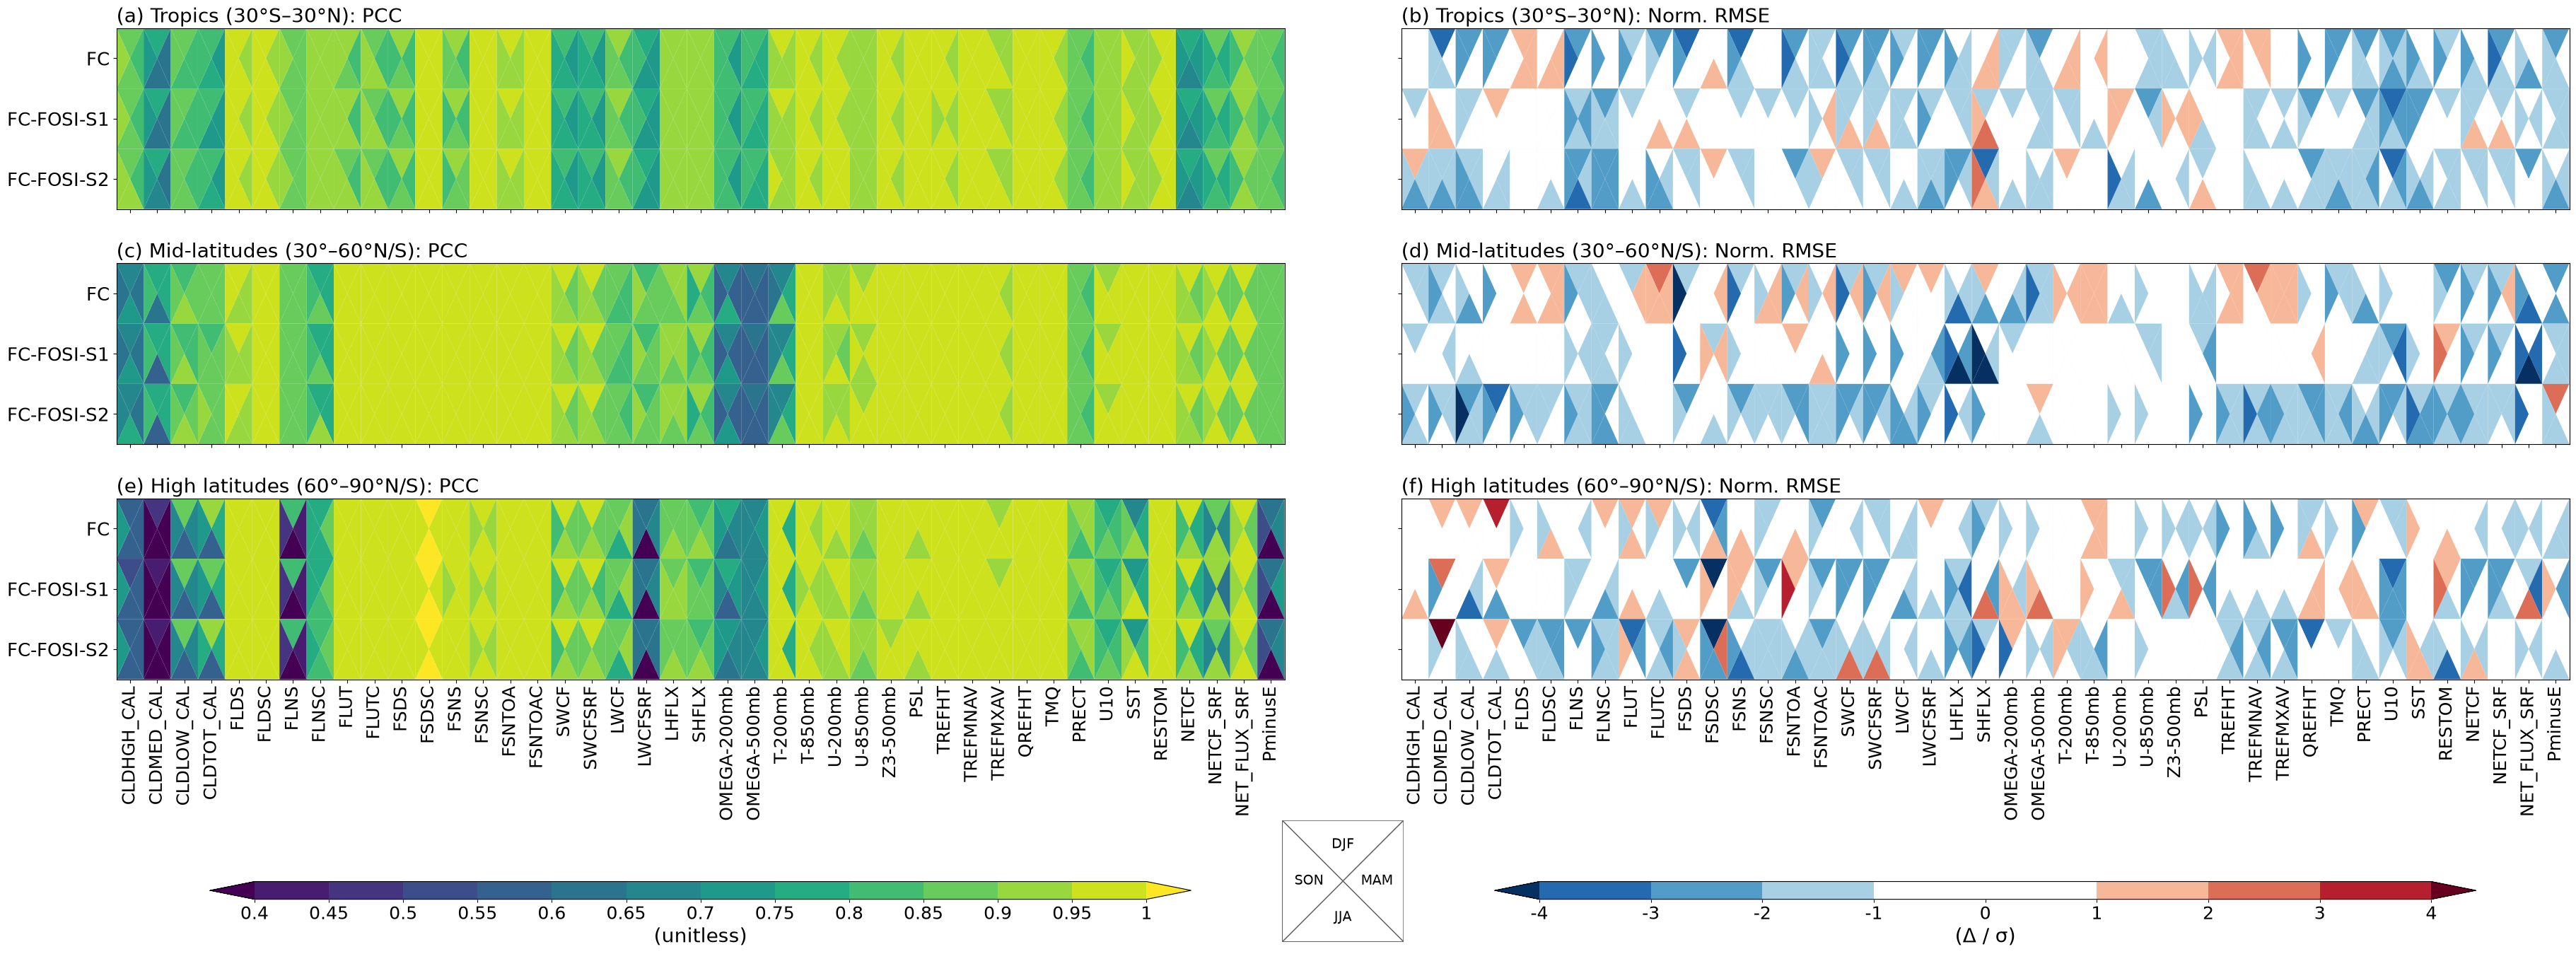

[INFO] Saved figure: /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper/figures/model_error_compare/SEAS1_exp3_PCC_RMSEz_regions_0301-0350.pdf
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed diagnostic dataset handle.
[INFO] Closed di

In [7]:
# load the per-band diagnostics saved by the loop above
analyzers_by_region = {}
for band in regions_to_plot:
    analyzers_by_region[band] = {}
    for e in experiments:
        analyzers_by_region[band][e] = {}
        for s in seasons:
            an = SpinupMetricAnalyzer(base_dir=os.path.join(regional_root, band),
                                      spinup_name=run_dict[e]["spin-up"]["name"])
            an.load_dataset(os.path.join(out_dir, f"{e}_spinup_diagnostics_{s}_{band}.nc"))
            an.select_variables(vars_to_plot)          # same variables/order as the global figure
            analyzers_by_region[band][e][s] = an

regions_outfile = os.path.join(fig_dir, f"SEAS1_exp3_PCC_RMSEz_regions_{comparison_period}.pdf")
analyzers_by_region[next(iter(regions_to_plot))][experiments[0]][seasons[0]].plot_heatmap_regions_pcc_rmse(
    analyzers_by_region=analyzers_by_region,
    region_titles=regions_to_plot,          # row order and titles
    experiments=experiments,
    explabels=explabels,
    period_label=comparison_period,
    fig_path=regions_outfile,
    pcc_discrete=pcc_discrete,
    pcc_bins=pcc_bins,
    pcc_label=pcc_label,
    rmse_mode=rmse_mode,
    rmse_discrete=rmse_discrete,
    rmse_bins=rmse_bins,
    rmse_label=rmse_label,
    title="",                               # e.g. f"Model error by latitude band ({comparison_period})"
    fontz=fontz,
    figsize=None,                           # auto from the number of variables/regions
    x_step=x_step,
    show_season_box=show_season_box,
    draw_grid=draw_grid,
    hatch_nan=hatch_nan,
)

for band in analyzers_by_region:
    for e in experiments:
        for s in seasons:
            analyzers_by_region[band][e][s].close()

publish(FIG_DIR, DATA_DIR)
print("web:", regions_outfile.replace(OUTPUT_ROOT, OUTPUT_URL))